# Wykład 7: Transfer learning w fastai
### Biblioteki Python w analizie danych
**Tomasz Rodak**

## Motywacja: granice trenowania od zera

Na końcu wykładu 5 sformułowaliśmy diagnozę: MLP daje sobie radę z danymi tabelarycznymi, ale na obrazach jest źle — liczba parametrów rośnie kwadratowo z rozdzielczością, a model nie ma żadnej wbudowanej wiedzy o lokalności ani niezmienniczości translacyjnej. Wykład 6 pokazał, że tę lukę zapełniają sieci konwolucyjne: warstwy `nn.Conv2d` współdzielą wagi w przestrzeni i mają wbudowaną hipotezę o tym, że to, co rozpoznajemy w obrazie, jest lokalne i podlega translacji razem z obiektem.

Lab 11 pokazał co można osiągnąć, gdy się sieć buduje samemu od zera. Własna CNN, kilkanaście warstw konwolucyjnych z BatchNorm i poolingiem, klasyfikacja CIFAR-10 — po piętnastu epokach dokładność rzędu osiemdziesięciu procent. Solidnie, jak na samodzielnie zaprojektowany model na laptopie, ale to wciąż daleko od poziomu, na którym klasyfikacja obrazów jest faktycznie *użyteczna* w realnych zadaniach.

Spójrzmy na skalę. CIFAR-10 to zbiór ćwiczeniowy — sześćdziesiąt tysięcy obrazów dwadzieścia osiem na dwadzieścia osiem pikseli, dziesięć klas, sześć tysięcy próbek na klasę. Realne zadanie klasyfikacji, z jakim spotka się analityk w firmie albo w laboratorium, wygląda zupełnie inaczej: kilkaset do kilku tysięcy obrazów w rozdzielczości 224×224 albo większej, od dziesięciu do tysiąca klas, często mocno nierównomiernie rozłożonych. Klas, dla których mamy po sto, dwieście próbek, jest tam zwykle więcej niż tych, dla których mamy ich tysiąc.

W tym miejscu pojawia się problem skali parametrów. ResNet-18 ma ponad 11,5 miliona parametrów — ponad dwadzieścia razy więcej niż nasza domowa CNN z CIFAR-10. Próba wytrenowania tylu parametrów od zera na zbiorze z pięcioma setkami obrazów na klasę nie tylko zajęłaby dziesiątki godzin GPU; nie zbiegnie się do niczego użytecznego, nawet z najmocniejszą regularyzacją. Ilość danych potrzebnych do nauczenia sieci tej wielkości "od podstaw" mierzymy w milionach obrazów, nie w setkach.

Sieci trenowane na tak ogromnych datasetach rzeczywiście istnieją. ImageNet, klasyczny benchmark wizualny, zawiera 1,2 miliona zdjęć i tysiąc klas. ResNet wytrenowany na ImageNet osiągnął na nim ponad siedemdziesiąt procent dokładności już w 2015 roku. Wagi takiego modelu — jego konwolucje, biasy, parametry BatchNorm — są ogólnodostępne. Czy potrafimy je wykorzystać do *innego* zadania, którego ResNet z ImageNet nigdy nie widział?

Tak, i to jest centralna technika tego wykładu. Zamiast trenować sieć od zera, **dostosowujemy** model wytrenowany na dużym zbiorze ogólnym do mniejszego zbioru specyficznego dla naszego zadania. Tę procedurę nazywamy *transfer learning* — uczeniem przez transfer.

## Idea: co właściwie transferujemy

Zanim opiszemy mechanikę, warto zrozumieć, dlaczego transfer w ogóle ma szansę zadziałać. Dlaczego cechy nauczone na obrazach kotów, psów, łodzi, lamp i dziewięciuset dziewięćdziesięciu sześciu innych klas miałyby pomóc w klasyfikacji obrazów, których ImageNet nigdy nie widział?

Odpowiedź ma postać hierarchii. Sieć konwolucyjna nie uczy się rozpoznawania klas w jednym kroku — buduje się to stopniowo, warstwa po warstwie:

* **Wczesne warstwy** uczą się detektorów uniwersalnych: krawędzi, gradientów jasności, prymitywnych tekstur. Filtry pierwszej warstwy konwolucyjnej ResNeta wyglądają dokładnie jak detektory ukośnych krawędzi i gradientów koloru — i to jest własność uniwersalna każdego naturalnego obrazu, niezależnie od tego, co przedstawia.

* **Środkowe warstwy** łączą te pierwotne cechy w bardziej złożone wzorce: rogi, pętle, faktury powierzchni, regularne układy linii. Te cechy są wciąż w dużej mierze niezależne od konkretnej klasy — róg jest rogiem niezależnie od tego, czy należy do skrzydła ptaka, czy do dachu domu.

* **Późne warstwy** odpowiadają już za cechy semantyczne specyficzne dla zadania, na którym sieć była trenowana: "to wygląda jak ucho psa", "to wygląda jak koło samochodu", "to wygląda jak pióro". Tu już silnie wchodzimy w to, co ImageNet "umie" — kategorie, do których ImageNet etykietuje swoje obrazy.

::: {.callout-note}
## Zastrzeżenie
Jest to jednak opis interpretacyjny, a nie dosłowna mapa działania sieci. Wczesne warstwy CNN są zwykle dość łatwe do powiązania z prostymi cechami wizualnymi, ale im głębiej w model, tym bardziej reprezentacje stają się rozproszone, zależne od zadania i trudniejsze do jednoznacznego nazwania. Dlatego sformułowania typu „detektor ucha psa” czy „detektor koła” należy rozumieć jako skrótowy opis wzorców aktywacji, a nie jako gwarancję istnienia pojedynczych, czysto semantycznych modułów.
:::

Konsekwencja dla transferu jest bezpośrednia. Wczesne i środkowe warstwy nauczyły się czegoś, czego potrzebujemy *zawsze*, niezależnie od zadania. Późne warstwy nauczyły się czegoś, czego potrzebujemy *czasami*, w zależności od tego, jak bardzo nasze zadanie przypomina ImageNet. Ostatnia warstwa głowy — `nn.Linear` z tysiącem wyjść na tysiąc klas ImageNet — jest dla nas zwykle wręcz bezużyteczna, bo klasy w naszym zadaniu i ich liczba są inne.

Stąd plan działania. Sieć w transferze dzielimy na dwie części:

* **Backbone** (kręgosłup) — wszystkie warstwy konwolucyjne aż do końca części feature-extracting. **Zachowujemy** je w całości, z wagami pretrenowanymi.

* **Head** (głowa) — końcowe warstwy w pełni połączone, mapujące zagregowaną reprezentację obrazu na klasy. **Wymieniamy** je na nowe, świeżo zainicjalizowane, dopasowane do liczby klas w *naszym* zadaniu.

W zależności od tego, jak agresywnie chcemy dostosować pretrenowane wagi, mamy dwa warianty:

* **Ekstrakcja cech** (*feature extraction*) — backbone jest *zamrożony* (`requires_grad=False` dla wszystkich jego parametrów, gradient nie płynie przez nie wstecz), trenujemy tylko nową głowę. Sieć pełni wówczas rolę ustalonego ekstraktora cech, a głowa jest klasycznym klasyfikatorem nad tymi cechami. Wariant ten jest szybki i zaskakująco dobrze działa, zwłaszcza gdy nasz zbiór jest mały.

* **Strojenie** (*fine-tuning*) — odmrażamy całą sieć i trenujemy wszystkie warstwy, ale z różnymi prędkościami uczenia: bardzo małym dla wczesnych warstw (nie chcemy zepsuć tego, co już działa) i większym dla nowej głowy (musi się jeszcze nauczyć). Wariant ten daje zwykle lepsze wyniki, ale za cenę nieco większego kosztu obliczeniowego i konieczności staranniejszego doboru learning rate'u.

Kiedy transfer w ogóle działa? Najlepiej wtedy, gdy nasza dystrybucja danych jest podobna do tej, na której pretrenowany był backbone. Dla zdjęć obiektów w naturalnym świetle, kolorowych, w typowych kompozycjach — czyli dokładnie takich, jakimi jest ImageNet — transfer działa zaskakująco dobrze. Dla obrazów radiologicznych, satelitarnych czy mikroskopowych jest słabiej; cechy z ImageNet są tam mniej trafione i sieć musi sporo "oduczyć się" w trakcie strojenia. Ale nawet w tych trudniejszych przypadkach transfer prawie zawsze pozostaje **lepszy niż losowa inicjalizacja** — bo nawet zła wstępna parametryzacja sieci jest lepsza od żadnej.

## ResNet w pigułce

ResNet poznaliśmy już na lab 11. Tu uzupełnimy tylko jeden brakujący element koncepcyjny, który decyduje o tym, dlaczego ResNet w ogóle dał się wytrenować w głębokiej wersji.

Klocek `BasicBlock`, (`print(model)` w lab 11), ma postać

\begin{equation*}
y = F(x) + x,
\end{equation*}

gdzie $F$ to zazwyczaj dwie konwolucje 3×3 przeplecione BatchNormem i aktywacją. To jest tak zwane **połączenie rezydualne** (*skip connection*): warstwy uczą się nie nowej funkcji od zera, lecz *odchylenia* od identyczności. Jeśli najlepszą rzeczą, jaką dany blok mógłby zrobić, jest niezmienianie wejścia — wystarczy, by $F \approx 0$, co dla losowej inicjalizacji jest naturalnym punktem startowym.

Konsekwencja jest dwojaka. Po pierwsze, gradient ma "autostradę" przez skip connection: w trakcie wstecznej propagacji propaguje się on wprost przez kanał $x$, omijając $F$. Dzięki temu nie zanika nawet w bardzo głębokich sieciach. Po drugie, sieć z połączeniami rezydualnymi *nie* jest gorsza niż jej płytsza wersja. Liczymy na to, że w najgorszym razie sieć nauczy się, że dane bloki to identyczność, i odtworzy zachowanie sieci krótszej. To pozwoliło He i współpracownikom w 2015 roku bezpiecznie zwiększyć głębokość ResNeta do 152 warstw, podczas gdy VGG dławił się przy dziewiętnastu.

Dla naszych celów w całym kursie wystarczy domyślny **ResNet-18** (około 11,7 miliona parametrów): jest dostatecznie pojemny, by dawać świetne wyniki w transferze, i wystarczająco mały, by trenować się w kilka minut na bezpłatnym GPU w Google Colab. Użyjemy go w sekcji 10 i ponownie w lab 12.

## fastai

Filozofia fastai daje się streścić w jednym zdaniu: *high-level API over PyTorch*. Każda funkcja fastai jest, pod spodem, wrapperem nad konkretnym mechanizmem PyTorcha, który już znamy. Nie ma w fastai magii, której nie umielibyśmy zaimplementować sami — jest tylko **automatyzacja powtarzalności** i **rozsądne ustawienia domyślne** w każdym miejscu, gdzie normalnie trzeba by je było wybierać ręcznie.

Co fastai daje konkretnie:

* sensowne wartości domyślne harmonogramu learning rate'u, augmentacji, normalizacji, regularyzacji i wyboru optymalizatora,
* trzy podstawowe abstrakcje (`DataLoaders`, `Learner`, `Learner.fine_tune()`), w których zawiera się kompletny pipeline,
* zestaw narzędzi interpretacyjnych (sekcja 11),
* skalowalny zestaw rozszerzeń: do tekstu, do tabel, do segmentacji, do rekomendacji.

Skutek jest taki, że kompletny pipeline klasyfikacji obrazów ma w fastai sześć linii kodu. Istotne jest abyśmy rozumieli, że fastai dostarcza bardzo zwięzłego interfejsu do tego, co już umiemy robić w PyTorchu.

Najwygodniej zacząć od mapy. W tabeli poniżej zestawiamy podstawowe pojęcia fastai z ich odpowiednikami w czystym PyTorchu.

| fastai                                  | PyTorch (wykłady 4–5, lab 11)                                                |
|-----------------------------------------|------------------------------------------------------------------------------|
| `DataLoaders`                           | dwa obiekty `torch.utils.data.DataLoader` (treningowy + walidacyjny)         |
| `Learner`                               | `nn.Module` + `optim.SGD/Adam` + funkcja straty + pętla treningowa           |
| `learn.fit()`                           | kanoniczna pętla treningowa z wykładu 5                                      |
| `learn.fine_tune()`                     | dwie pętle treningowe z wymianą `requires_grad` między nimi                  |
| `vision_learner(..., resnet18)`         | pobranie pretrenowanego modelu + podmiana `fc` + zamrożenie (z lab 11)        |
| `lr_find()`                             | pętla po batchach z wykładniczo rosnącym LR i logowaniem straty              |

Wniosek praktyczny: **fastai nie robi niczego, czego nie umielibyśmy zaimplementować w PyTorchu**. Niemal cały zysk fastai pochodzi z dwóch źródeł — z faktu, że ktoś *raz* napisał te rzeczy poprawnie (z dobrym harmonogramem, sensowną normalizacją, augmentacjami, które działają), oraz z tego, że trzy podstawowe abstrakcje są dobrze dobrane do tego, co naprawdę robimy w trenowaniu modeli.

W kolejnych sekcjach omówimy te abstrakcje w kolejności, w jakiej sięga się po nie w praktyce: najpierw `DataBlock` i `DataLoaders` (sekcja 5), potem `vision_learner` (sekcja 6), potem ręcznie zaimplementujemy `fine_tune()` w czystym PyTorchu (sekcja 7), zobaczymy `lr_find()` (sekcja 8) i fastai-ową wersję `fine_tune()` (sekcja 9). Wreszcie w sekcji 10 zobaczymy całość w działaniu.

## API `DataBlock` — deklaratywne przygotowanie danych

W lab 11 pisaliśmy ręcznie definicję `Dataset`, oddzielne transformacje train i test, splittery, `DataLoader`. Każdy nowy zbiór wymagał napisania prawie identycznego boilerplate'u. fastai zamiast pisania kodu pozwala **opisać** dane — i z tego opisu samo skonstruuje wszystko, co PyTorch potrzebuje.

Centralną abstrakcją jest klasa `DataBlock`. Skonstruowana z kilku komponentów, każdy w jednej linijce:

In [ ]:
#| eval: false
from fastai.vision.all import *

dblock = DataBlock(
    blocks=(ImageBlock, CategoryBlock),
    get_items=get_image_files,
    splitter=RandomSplitter(valid_pct=0.2, seed=42),
    get_y=parent_label,
    item_tfms=Resize(224),
    batch_tfms=[*aug_transforms(), Normalize.from_stats(*imagenet_stats)],
)


Każdy z tych komponentów odpowiada na jedno konkretne pytanie o dane:

* **`blocks=(ImageBlock, CategoryBlock)`** — co jest wejściem, a co wyjściem? Tu: obraz jako wejście, kategoria jako wyjście. Inne dostępne bloki to `MultiCategoryBlock` (klasyfikacja wieloetykietowa), `RegressionBlock` (regresja), `MaskBlock` (segmentacja). Wybór bloku wyjściowego determinuje też domyślną funkcję straty.

* **`get_items`** — skąd brać próbki? Funkcja zwracająca listę elementów (zwykle ścieżek do plików). Standardowo `get_image_files`, która rekursywnie przeszukuje folder w poszukiwaniu obrazów.

* **`splitter`** — jak dzielić na zbiór treningowy i walidacyjny? Najczęściej `RandomSplitter(valid_pct=0.2, seed=42)` — losowy podział 80/20 z ustalonym ziarnem. Dostępne są też `GrandparentSplitter` (gdy folder z danymi ma już strukturę `train/` i `valid/`), `IndexSplitter`, `FuncSplitter`.

* **`get_y`** — jak wyłuskać etykietę z elementu listy? Dla obrazów zorganizowanych po folderach (folder na klasę) wystarczy `parent_label` (etykietą jest nazwa katalogu, dokładnie jak w PyTorchowym `ImageFolder`). Dla nazw plików kodujących klasę używamy `using_attr(RegexLabeller(r'^(.+)_\d+.jpg$'), 'name')` — zobaczymy to w sekcji 10 na zbiorze Pets.

* **`item_tfms`** — transformacje pojedynczych próbek wykonywane na CPU, **przed** złożeniem w batch. Tu najczęściej `Resize(224)` — bo `DataLoader` nie może złożyć w batch obrazów o różnych rozdzielczościach.

* **`batch_tfms`** — transformacje całych batchy wykonywane na GPU. Tu trafiają augmentacje (`aug_transforms()` daje rotacje, odbicia, zoom, modulacje jasności i kontrastu z rozsądnymi domyślnymi ustawieniami) oraz normalizacja statystykami ImageNet (`Normalize.from_stats(*imagenet_stats)`).

Punkt, który warto podkreślić: **normalizacja statystykami ImageNet** to nie jest kosmetyczny detal. ResNet backbone był trenowany na wejściach znormalizowanych tymi konkretnymi statystykami (średnie kanałów: 0,485 / 0,456 / 0,406; odchylenia: 0,229 / 0,224 / 0,225). Jeśli podamy mu obraz z innym rozkładem wejść — na przykład z zakresu [0, 1] bez normalizacji — to wczesne warstwy nadal wykonają swoje konwolucje, ale wyniki nie będą leżały w zakresie, dla którego trenowały się następne warstwy. Cechy "nie działają". W transferze pretrenowanego modelu używanie statystyk z ImageNet jest **konieczne**.

Mając `DataBlock`, wywołujemy go na konkretnym folderze, dostając obiekt `DataLoaders` zawierający dwa wewnętrzne loadery:

In [ ]:
#| eval: false
dls = dblock.dataloaders(path, bs=64)

Pierwszy krok każdej analizy z fastai to **sanity check** za pomocą `dls.show_batch(max_n=9)` — siatka dziewięciu obrazów z etykietami:

In [ ]:
#| eval: false
dls.show_batch(max_n=9)


To wygląda banalnie, ale w praktyce wyłapuje się tu większość błędów: złe etykiety, zbyt agresywne augmentacje (`Resize` zniekształcający proporcje), źle rozpakowane archiwa. Pierwsza minuta z `show_batch` oszczędza zwykle godzinę debugowania po treningu.

## `vision_learner`

Mając przygotowany `DataLoaders`, tworzymy `Learner` jedną linijką:

In [ ]:
#| eval: false
learn = vision_learner(dls, resnet18, metrics=accuracy)


Pod spodem fastai wykonuje cztery rzeczy. Wszystkie znamy z lab 11.

**Po pierwsze**, pobiera pretrenowany ResNet-18 z internetu (albo z lokalnego cache, jeśli już go ściągaliśmy) i ładuje wagi z ImageNet. Czyli to, co robił `resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)` w lab 11.

**Po drugie**, odcina oryginalną głowę `fc` (linijka mapująca 512 cech na 1000 klas ImageNet) i przykleja w jej miejsce nową głowę, składającą się z kilku warstw: adaptive average pooling, flatten, BatchNorm, Dropout, Linear z aktywacją ReLU, kolejny BatchNorm i Dropout, i wreszcie warstwa Linear o wymiarze wyjściowym równym liczbie klas w `dls`. Głowa fastai jest więc bogatsza niż prosta podmiana `fc` z lab 11 (jedna warstwa liniowa), ale idea jest dokładnie ta sama: wymieniamy "ogon" sieci na coś dostosowanego do liczby naszych klas.

**Po trzecie**, zamraża backbone. W pętli po parametrach całej sieci ustawia `requires_grad=False` wszędzie poza nową głową:

In [ ]:
#| eval: false
for p in backbone.parameters():
    p.requires_grad = False


To zamrożenie jest punktem startowym strojenia: pierwsza faza treningu uczy tylko nową głowę.

**Po czwarte**, dobiera funkcję straty. Z typu bloku wyjściowego — w naszym przypadku `CategoryBlock` — fastai automatycznie wnioskuje, że potrzebujemy klasyfikacji wieloklasowej, i ustawia `CrossEntropyLossFlat` (wariant `nn.CrossEntropyLoss` z dodatkowym wypłaszczeniem wejścia, gdyby przyszło o niestandardowym kształcie).

## Transfer learning w czystym PyTorch — pełny przykład

Sekcja ta ma za zadanie pokazać, że to, co fastai robi w jednej linijce `fine_tune()`, to **dwie kanoniczne pętle treningowe z wykładu 5**, między którymi zmieniamy `requires_grad` i wprowadzamy nową strukturę optymalizatora. Nic poza tym. Kod poniżej jest celowo konceptualny — pominęliśmy ładowanie danych, definicję `device`, kompletne pętle ewaluacji — tak żeby było widać samą strukturę procedury.

**Setup.** Pobieramy pretrenowany ResNet-18, zamrażamy całość, podmieniamy głowę na nową.

In [ ]:
#| eval: false
from torchvision.models import resnet18, ResNet18_Weights

model = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)

# Zamrożenie backbone
for p in model.parameters():
    p.requires_grad = False

# Nowa głowa
n_classes = 37
model.fc = nn.Linear(model.fc.in_features, n_classes)
model = model.to(device)

criterion = nn.CrossEntropyLoss()


**Etap 1 — trening tylko głowy.** Backbone jest zamrożony, więc gradient nie płynie przez niego wstecz. Optymalizator dostaje tylko parametry nowej głowy. Jedna lub dwie epoki wystarczą, by głowa się "ustawiła" na nowych klasach.

In [ ]:
#| eval: false
optimizer = optim.Adam(model.fc.parameters(), lr=1e-3)

for epoch in range(1):
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        loss = criterion(model(x), y)
        loss.backward()
        optimizer.step()


**Etap 2 — odmrożenie i strojenie z dyskryminacyjnym LR.** Tu pojawia się jedyny prawdziwie nowy mechanizm tego wykładu: **dwie grupy parametrów w tym samym optymalizatorze, każda z innym learning rate'em**.

In [ ]:
#| eval: false
# Odmrażamy wszystko
for p in model.parameters():
    p.requires_grad = True

# Backbone = wszystko poza nową głową
backbone_params = [p for n, p in model.named_parameters() if not n.startswith('fc.')]
head_params = list(model.fc.parameters())

optimizer = optim.Adam([
    {'params': backbone_params, 'lr': 1e-5},   # bardzo mały LR — nie psujemy cech
    {'params': head_params,     'lr': 1e-3},   # 100× większy dla głowy
])

for epoch in range(3):
    for x, y in train_loader:
        # ... ta sama pętla co w etapie 1 ...
        pass


Cała nowość siedzi w trzech linijkach: zamiast jednego `lr=...` przekazujemy do `optim.Adam` **listę słowników**, każdy ze swoją grupą parametrów i swoim learning rate'em. Ten mechanizm — `param_groups` — jest standardową cechą PyTorcha. Wspomnieliśmy o niej w wykładzie 5 jako o ciekawostce; tu używamy jej pierwszy raz na poważnie.

**Dlaczego dyskryminacyjny LR.** Trzy obserwacje, które razem motywują tę konstrukcję:

* Backbone jest "prawie dobry" — jego wagi są już blisko optimum dla problemu wizualnego. Duży LR popsułby tę reprezentację, bo gradient w stosunku do dobrze wytrenowanej sieci jest mały, ale każdy duży krok wystarczy, by ją zdestabilizować. Mały LR (rzędu $10^{-5}$) pozwala go *delikatnie dostroić* do naszego zadania.
* Głowa jest świeżo zainicjalizowana — losowo. Musi się uczyć od zera. Mały LR w głowie znaczyłby, że pierwsze kilka epok jest dla niej zupełnie nieproduktywne. Stąd LR rzędu $10^{-3}$.
* Empirycznie sensowna proporcja między LR backbone'u i głowy to 10–100×. Mniejsza nie wykorzystuje w pełni elastyczności głowy; większa zaczyna psuć backbone.

Czterdzieści linijek kodu, które właśnie napisaliśmy, to ekwiwalent `fine_tune(3)`.

## `lr_find()` — empiryczny dobór learning rate'u

Learning rate jest hiperparametrem o największym wpływie na trening. Za mały — sieć się nie uczy, strata schodzi w żółwim tempie. Za duży — strata oscyluje albo wybucha. Pamiętamy z wykładu 4 i lab 7 (sekcja 3), jak czuły jest GD na dobór $\eta$.

Skąd brać dobrą wartość? W teorii moglibyśmy stroić ją Optuną. W praktyce w głębokim uczeniu robimy coś tańszego: uruchamiamy **jednorazową, krótką pętlę diagnostyczną**, w trakcie której LR rośnie i obserwujemy, jak strata na to reaguje.

Algorytm zaproponowany przez [Leslie Smitha w 2017](https://ieeexplore.ieee.org/abstract/document/7926641) roku (i zaimplementowany w fastai jako `learn.lr_find()`) jest prosty:

1. Rozpocznij od bardzo małej wartości LR (zwykle $10^{-7}$).
2. W każdym mini-batchu zwiększaj LR wykładniczo, tak by w ciągu ~100 batchów dojść do wartości bardzo dużej (zwykle 10).
3. Po każdym kroku zapisz aktualne LR i odpowiadającą mu wartość straty.
4. Przerwij, gdy strata wystrzeli w górę o rząd wielkości.
5. Narysuj krzywą strata–LR (na osi $x$ skala logarytmiczna).

Krzywa, którą dostajemy, ma charakterystyczny kształt — trzy fazy:

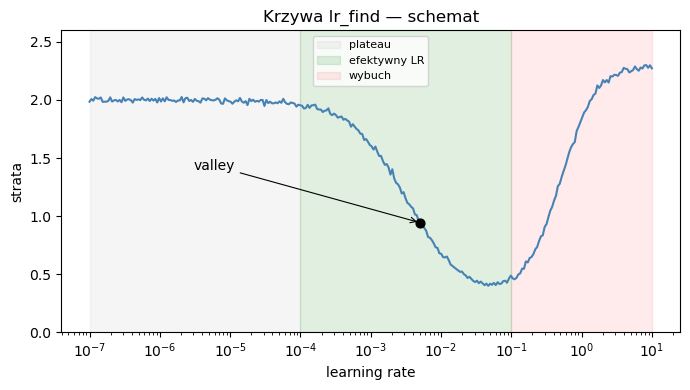

In [ ]:
#| eval: false
#| echo: false
# Pseudoschemat krzywej lr_find — narysowany ręcznie, nie z prawdziwego treningu
import numpy as np
import matplotlib.pyplot as plt

lrs = np.logspace(-7, 1, 300)
u = np.log10(lrs)

# Trzy fazy: plateau (mały LR), spadek (efektywny LR), wybuch (za duży LR)
def curve(u):
    descent   = 1.7 / (1 + np.exp(-2.5 * (u + 2.5)))   # strata spada
    explosion = 2.0 / (1 + np.exp(-4.0 * (u + 0.3)))   # strata wybucha
    return 2.0 - descent + explosion

loss = curve(u) + np.random.normal(0, 0.015, len(lrs))

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(lrs, loss, color='steelblue', lw=1.5)
ax.set_xscale('log')
ax.set_ylim(0, 2.6)
ax.set_xlabel('learning rate')
ax.set_ylabel('strata')
ax.set_title('Krzywa lr_find — schemat')

ax.axvspan(1e-7, 1e-4, alpha=0.08, color='gray',  label='plateau')
ax.axvspan(1e-4, 1e-1, alpha=0.12, color='green', label='efektywny LR')
ax.axvspan(1e-1, 1e+1, alpha=0.08, color='red',   label='wybuch')

# valley — punkt policzony z tej samej krzywej, więc zawsze leży na linii
valley_lr = 5e-3
valley_loss = curve(np.log10(valley_lr))
ax.scatter([valley_lr], [valley_loss], color='black', zorder=5, s=40)
ax.annotate('valley', xy=(valley_lr, valley_loss),
            xytext=(3e-6, 1.4),
            arrowprops=dict(arrowstyle='->', lw=0.8))

ax.legend(loc='upper center', fontsize=8)
plt.tight_layout()
plt.show()

Co widzimy na takiej krzywej:

* **Plateau przy bardzo małym LR.** Sieć się nie uczy, strata jest mniej więcej stała. Gradient jest mnożony przez tak mały LR, że krok parametru jest poniżej szumu.
* **Ostry spadek przy umiarkowanym LR.** Sieć uczy się efektywnie — strata szybko maleje wraz ze wzrostem LR. To jest "dobre" pasmo, z którego chcemy wybrać wartość.
* **Wybuch przy zbyt dużym LR.** Strata zaczyna gwałtownie rosnąć. Kroki są na tyle duże, że parametry wylatują w obszary, w których funkcja straty jest gorsza niż przed nimi. Zwykle w tym momencie pętla się przerywa.

Z tej krzywej fastai zwraca propozycję learning rate'u — domyślnie wartość zwaną **`valley`**. Algorytm `valley` lokalizuje najdłuższą „dolinę" na krzywej (najdłuższy spójny fragment, na którym strata maleje) i wybiera punkt mniej więcej w 2/3 jej długości — czyli wewnątrz pasma efektywnego uczenia, jeszcze z bezpiecznym zapasem od obszaru wybuchu. To rozsądny, konserwatywny default, który w praktyce sprawdza się dla większości zadań transferowych.

Wynik `lr_find()` to obiekt, z którego wyłuskujemy tę liczbę przez pole `.valley` i podajemy ją wprost do `fine_tune()`:

```python
res = learn.lr_find()
learn.fine_tune(3, base_lr=res.valley)
```

Tym samym `lr_find()` nie tylko rysuje krzywą, ale również dostarcza konkretną wartość `base_lr` do treningu. (fastai potrafi też zwrócić inne propozycje, np. punkt minimum czy najstromszego nachylenia, jeśli poda się je w `suggest_funcs`, ale domyślny `valley` wystarcza nam w zupełności.)

Interpretacja: `lr_find` to **tania, jednowymiarowa wersja Optuny**. Optuna przeszukuje wielowymiarową przestrzeń hiperparametrów, ucząc się rozkładu warunkowego dobrych kombinacji. `lr_find` szuka w jednym wymiarze (sam LR), ale wykonuje tę pracę w trakcie *jednej* krótkiej pętli, bez powtarzania pełnego treningu.

## `fine_tune()` — dwuetapowy trening w jednej linijce

Mając wartość z `lr_find()`, podajemy ją jako `base_lr` i wywołujemy:

```python
learn.fine_tune(epochs=3, base_lr=res.valley)
```

Pod spodem ta jedna linijka rozkłada się na to, co napisaliśmy ręcznie w sekcji 7, plus jeden bonus.

**Etap 1** (długość ustalana parametrem `freeze_epochs`, domyślnie 1 epoka): wywołuje `learn.freeze()`, co ustawia `requires_grad=False` we wszystkich warstwach poza nową głową, a następnie trenuje przez `freeze_epochs` epok z LR równym `base_lr`.

**Etap 2** (długość `epochs`): wywołuje `learn.unfreeze()`, co odmraża wszystkie warstwy, a następnie trenuje przez `epochs` epok z **dyskryminacyjnym LR**: bardzo małym dla wczesnych warstw backbone'u, większym dla nowej głowy. Wewnętrznie fastai dzieli parametry ResNeta na trzy grupy (wczesne warstwy backbone'u, środkowe warstwy backbone'u, nowa głowa) i przypisuje im learning rate'y na skali geometrycznej między `base_lr/100` a `base_lr/2`. To, co fastai konstruuje pod spodem, to **ta sama lista słowników z `params` i `lr`**, którą zbudowaliśmy ręcznie w sekcji 7 — tylko dla trzech grup zamiast dwóch, i z LR-ami obliczonymi automatycznie z `base_lr`. Tej konstrukcji nie wywołujemy sami; `fine_tune()` buduje ją za nas.

**One-cycle policy.** Bonus, którego sekcja 7 nie pokazywała: w obrębie każdego etapu LR nie jest stały, lecz harmonogramowany polityką jednego cyklu ([Smith 2018](https://arxiv.org/abs/1803.09820) — inna praca niż range test z sekcji 8). Znaleziona przez `lr_find` wartość `base_lr` pełni tu rolę **szczytu** harmonogramu: LR startuje od ułamka `base_lr`, rośnie do `base_lr` w początkowej części cyklu (domyślnie ~25% kroków), a potem kosinusowo opada do wartości bliskiej zeru. Intuicja jest dwojaka — faza narastania pomaga sieci wydostać się z marnego minimum, faza opadania pozwala jej „osadzić się" w dobrym. W czystym PyTorchu robi to `torch.optim.lr_scheduler.OneCycleLR`; w fastai dzieje się to automatycznie wewnątrz `fine_tune()`.

Zauważmy, jak ułożone są warstwy abstrakcji. Jedna linijka `fine_tune(3, base_lr=1e-3)` to: dwie pętle treningowe z wykładu 5, dyskryminacyjny LR z sekcji 7, plus harmonogram one-cycle.

## Praktyczny przykład: Oxford-IIIT Pets

Zobaczmy całość w działaniu. Zbiór, który tu wykorzystamy — Oxford-IIIT Pets — to jeden z klasycznych benchmarków klasyfikacji obrazów: 37 klas (różne rasy psów i kotów), około 7000 zdjęć w naturalnych warunkach, etykieta zapisana w nazwie pliku (np. `american_bulldog_42.jpg` → klasa `american_bulldog`).

Krok pierwszy — pobranie i podejrzenie danych:

In [1]:
#| eval: false
from fastai.vision.all import *

path = untar_data(URLs.PETS)
files = get_image_files(path/'images')
print(len(files), files[0])


7390 /root/.fastai/data/oxford-iiit-pet/images/Birman_117.jpg


`untar_data(URLs.PETS)` pobiera archiwum, rozpakowuje je do lokalnego cache fastai i zwraca ścieżkę do folderu z danymi. `get_image_files` zwraca listę wszystkich plików obrazów w folderze.

Etykietowanie wymaga wyłuskania nazwy rasy z nazwy pliku. Konwencja Oxford-IIIT: nazwa rasy może składać się z wielu słów rozdzielonych podkreśleniami, a po niej następuje `_<numer>.jpg`. Wyrażenie regularne `r'^(.+)_\d+.jpg$'` wyłuska część przed numerem.

Pełen pipeline w sześć linijek:

<div></div>

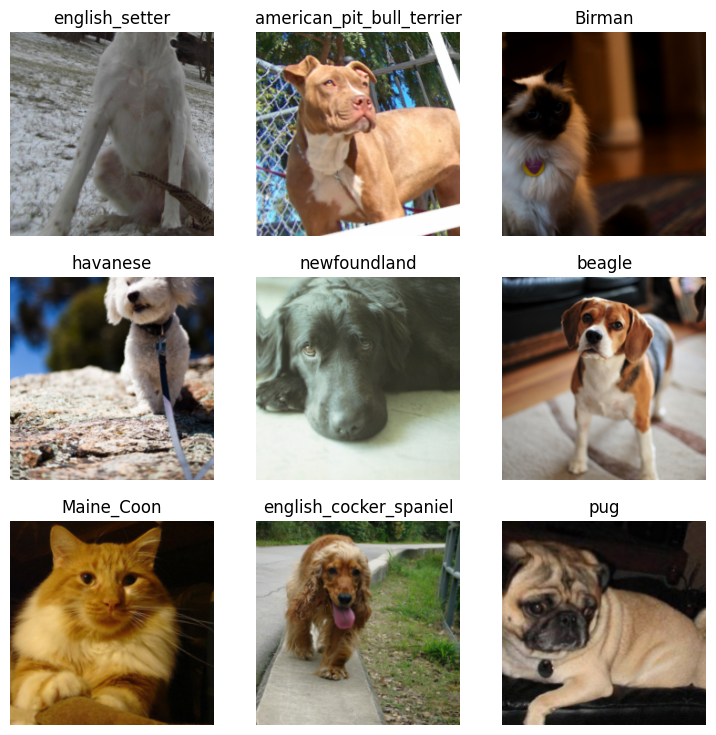

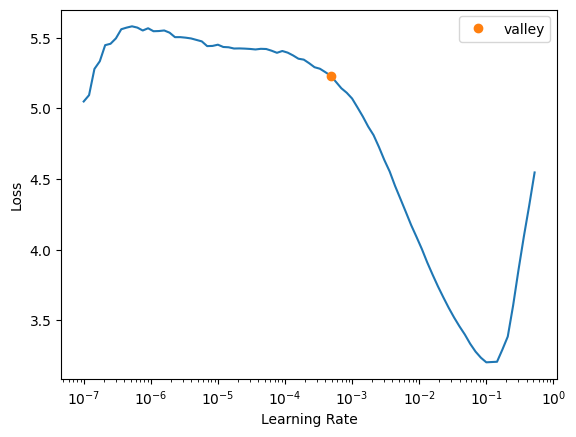

In [2]:
#| eval: false
dblock = DataBlock(
    blocks=(ImageBlock, CategoryBlock),
    get_items=get_image_files,
    splitter=RandomSplitter(valid_pct=0.2, seed=42),
    get_y=using_attr(RegexLabeller(r'^(.+)_\d+.jpg$'), 'name'),
    item_tfms=Resize(224),
    batch_tfms=[*aug_transforms(), Normalize.from_stats(*imagenet_stats)],
)
dls = dblock.dataloaders(path/'images', bs=64)
dls.show_batch(max_n=9)

learn = vision_learner(dls, resnet18, metrics=accuracy)
res = learn.lr_find()

In [3]:
learn.fine_tune(3, base_lr=res.valley)

epoch,train_loss,valid_loss,accuracy,time
0,2.897494,0.664590,0.817997,00:39


epoch,train_loss,valid_loss,accuracy,time
0,1.060126,0.379037,0.884980,00:41
1,0.722888,0.278782,0.908660,00:42
2,0.574418,0.267447,0.912720,00:45


Na Pets ten pipeline daje zwykle dokładność wyraźnie powyżej dziewięćdziesięciu procent na zbiorze walidacyjnym po trzech epokach. Pełny trening trwa około trzech minut na bezpłatnym GPU T4 w Google Colab — niewielki ułamek tego, ile zajęłoby trenowanie ResNeta od zera (które zresztą, jak zaraz zobaczymy, w ogóle by się nie udało).

**Porównanie z treningiem od zera.** Najprostszy sposób, żeby zobaczyć, ile naprawdę daje transfer, to wykonać dokładnie ten sam trening, ale z modelem zainicjalizowanym losowo — czyli `vision_learner(dls, resnet18, pretrained=False, metrics=accuracy)`. Liczba parametrów ta sama, architektura ta sama, dane te same, te same trzy epoki strojenia z `fine_tune`.

<div></div>

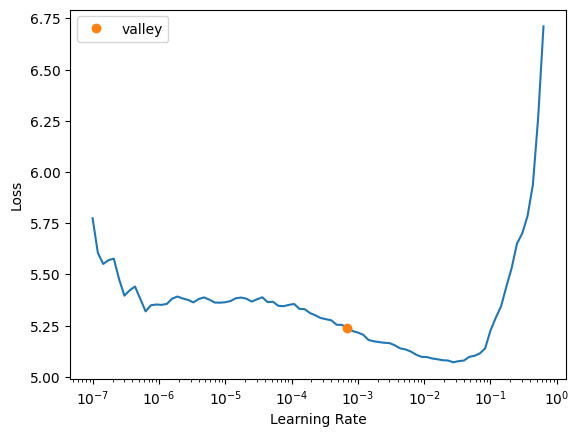

In [4]:
learn_raw = vision_learner(dls, resnet18, pretrained=False, metrics=accuracy)
res = learn_raw.lr_find()

In [5]:
learn_raw.fine_tune(3, base_lr=res.valley)

epoch,train_loss,valid_loss,accuracy,time
0,4.883750,3.785161,0.052097,00:39


epoch,train_loss,valid_loss,accuracy,time
0,4.368881,3.625672,0.071719,00:41
1,4.222616,3.437689,0.091340,00:42
2,4.101819,3.412164,0.099459,00:43


W tym porównaniu — 80 punktów procentowych różnicy między modelem pretrenowanym a modelem od zera, przy identycznej reszcie pipeline'u — widać sens transfer learningu.

## Interpretacja wyników

Po wytrenowaniu modelu w fastai mamy do dyspozycji zestaw narzędzi diagnostycznych zebranych w klasie `ClassificationInterpretation`:

In [6]:
#| eval: false
interp = ClassificationInterpretation.from_learner(learn)

Dwie wizualizacje, na które warto patrzeć zaraz po treningu:

**Macierz pomyłek.** `interp.plot_confusion_matrix(figsize=(12, 12))` rysuje macierz 37×37 pokazującą, która rasa myli się z którą. Na zbiorze Pets typowo widać dwa lub trzy "ciepłe" punkty poza diagonalą: Birman i Ragdoll (oba długowłose koty syjamskie), American Bulldog i Staffordshire Bull Terrier (oba muskularne psy o krótkiej sierści), Siamese i Birman. Te pomyłki **nie są błędem modelu** — są poprawną informacją o świecie. Te rasy są naprawdę wizualnie podobne; nawet specjalista bez kontekstu by się czasem pomylił.

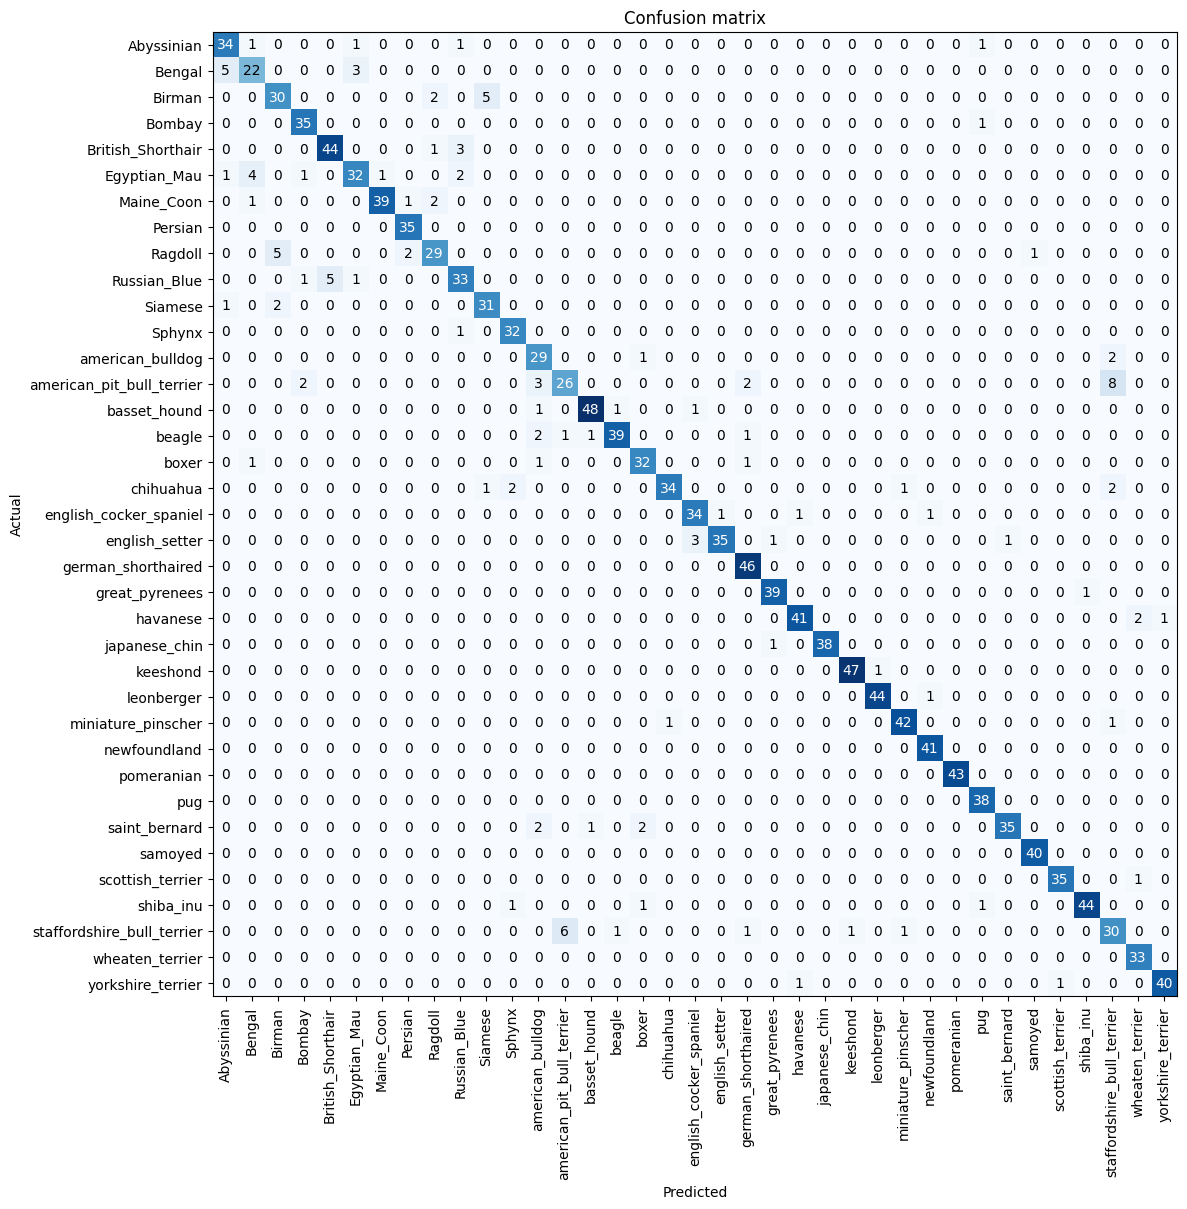

In [7]:
interp.plot_confusion_matrix(figsize=(12, 12))

**Najgorsze przypadki.** `interp.plot_top_losses(9, nrows=3)` rysuje dziewięć obrazów, na których model miał największą stratę. Dla każdego pokazane są: etykieta prawdziwa, predykcja modelu, jego pewność i wartość straty.

Te dziewięć obrazów zwykle dzieli się na trzy kategorie:

* **Obrazy faktycznie trudne** — zdjęcia, na których ras *naprawdę* nie da się rozróżnić bez szerszego kontekstu. Pies śpiący zwinięty w kłębek; kot na zdjęciu zrobionym pod światło; szczeniak w wieku, w którym jego rasa jest jeszcze niewykształcona.
* **Obrazy źle oznaczone w zbiorze**. Zdarza się to nawet w klasycznych benchmarkach. Pets ma kilkanaście błędów etykietowania; ImageNet ma tysiące. Top losses są najszybszym sposobem, żeby je znaleźć.
* **Obrazy spoza rozkładu**. Część pyska wystająca zza kanapy; zwierzę bardzo daleko; pies sfotografowany z dziwnego kąta; pies obok kota i etykieta wskazuje tylko jedno z nich.

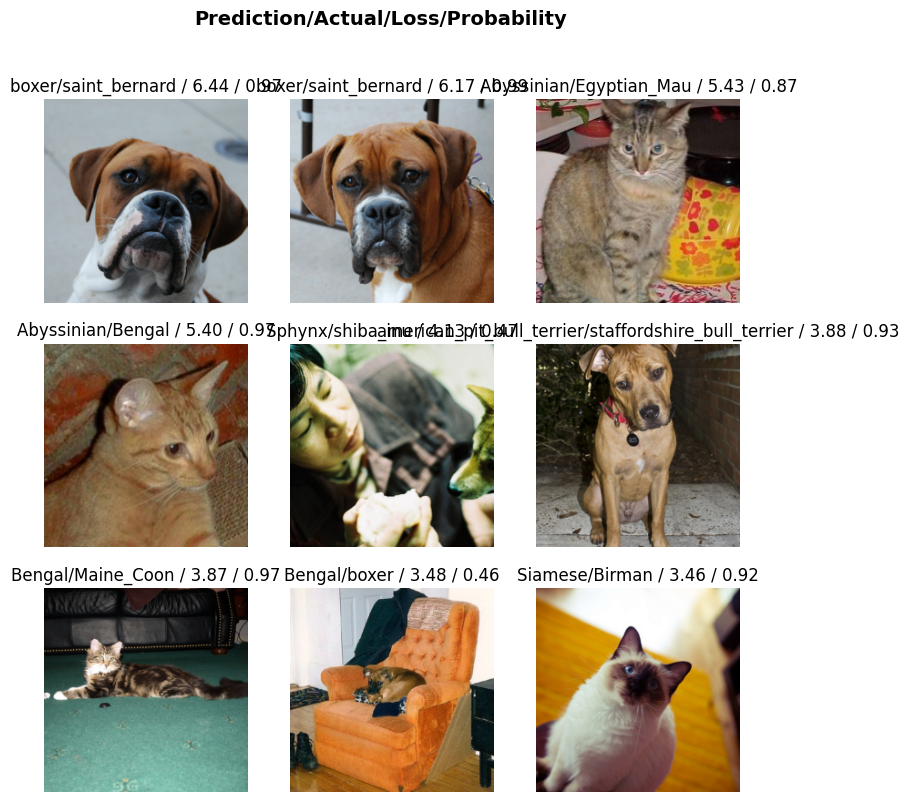

In [8]:
interp.plot_top_losses(9, nrows=3)

To prowadzi do punktu, który warto zapamiętać: **w praktyce osiemdziesiąt procent poprawy modelu pochodzi z poprawiania danych, nie modelu**. Nie z droższej architektury, nie z większego ResNeta, nie z dłuższego treningu — z obejrzenia top losses, identyfikacji błędnych etykiet, dosypania kilkudziesięciu zdjęć dla niedoreprezentowanej klasy.

## Spojrzenie na zewnątrz

Mechanizm, który pokazaliśmy na ResNet-18 i Pets — pretrening na ogromnym zbiorze ogólnym, a potem strojenie na małym zbiorze specyficznym — nie jest specjalnością obrazów. Dziś jest to **dominujący paradygmat w całym uczeniu maszynowym**.

W przetwarzaniu języka naturalnego mamy całą rodzinę pretrenowanych modeli językowych: BERT, RoBERTa, GPT i wiele innych. Każdy z nich jest trenowany na ogromnych korpusach tekstowych (dziesiątki gigabajtów tekstów z Wikipedii, książek, stron internetowych) w trybie samonadzorowanym — przewidywanie maskowanych słów, przewidywanie następnego słowa. Mając taki pretrenowany model, stroimy go do konkretnego zadania: klasyfikacji sentymentu, ekstrakcji nazwanych encji, klasyfikacji tematów. fastai ma własny moduł `text_learner` z analogicznym API do `vision_learner`, ale w praktyce dziś standardem branżowym jest biblioteka [Hugging Face Transformers](https://huggingface.co/docs/transformers), która udostępnia setki pretrenowanych modeli i pełne API do ich strojenia.

W przetwarzaniu dźwięku — to samo. Wav2Vec, Whisper i podobne modele są pretrenowane na milionach godzin nagrań audio, a potem strojone do transkrypcji w konkretnym języku, identyfikacji mówcy, klasyfikacji emocji.

W wideo, segmentacji semantycznej, detekcji obiektów, analizie obrazów medycznych, danych satelitarnych — wszędzie to samo. Zawsze ten sam plan: znajdź ogromny zbiór ogólny w tej samej modalności, pretrenuj na nim duży model, dostarcz go społeczności, niech każdy stroi do swojego zadania.

Granicą tego paradygmatu są **modele fundamentalne**: jeden bardzo duży model wytrenowany na ogromnym zbiorze danych ogólnych, do którego doczepiamy małe specyficzne głowy dla każdego konkretnego zadania. To podejście jest dziś szkieletem większości systemów AI w produkcji.

Wszystko to jest wariantem mechanizmu, który właśnie zobaczyliśmy w `fine_tune()`: backbone z pretrenowanymi wagami, świeża głowa pasująca do nowego zadania, dyskryminacyjny LR pozwalający delikatnie dostroić backbone, nie psując go. Skala inna, idea ta sama.